In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

In [2]:
DATA_PATH = Path("cka_regime_pivot_table.csv")

df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
df_raw.head()

(28, 4)


,model_1,model_2,coding_vs_coding,noncoding_vs_noncoding
0,GROVER,hyenadna-large-1m-seqlen-hf,0.426564,0.731800
1,GROVER,hyenadna-medium-450k-seqlen-hf,0.449215,0.737599
2,GROVER,nucleotide-transformer-2.5b-1000g,0.573169,0.731035
3,GROVER,nucleotide-transformer-2.5b-multi-species,0.432626,0.499975
4,GROVER,nucleotide-transformer-500m-human-ref,0.509024,0.530625


In [3]:
df_raw.info()
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   model_1                 28 non-null     object 
 1   model_2                 28 non-null     object 
 2   coding_vs_coding        28 non-null     float64
 3   noncoding_vs_noncoding  28 non-null     float64
dtypes: float64(2), object(2)
memory usage: 1.0+ KB


,coding_vs_coding,noncoding_vs_noncoding
count,28.000000,28.000000
mean,0.429914,0.559812
std,0.154747,0.128713
min,0.189615,0.369573
25%,0.328909,0.499483
50%,0.403394,0.538379
75%,0.533082,0.575897
max,0.843654,0.920020


In [ ]:
SHORT_NAMES = {
    "GROVER": "GROVER",
    "gena-lm-bigbird-base-t2t": "GENA-LM",
    "gpn-brassicales": "GPN",
    "hyenadna-large-1m-seqlen-hf": "HyenaDNA-L",
    "hyenadna-medium-450k-seqlen-hf": "HyenaDNA-M",
    "nucleotide-transformer-2.5b-1000g": "NT-2.5b-1000g",
    "nucleotide-transformer-2.5b-multi-species": "NT-2.5b-multi",
    "nucleotide-transformer-500m-human-ref": "NT-500m-human",
}

_seen: list[str] = []
for col in ("model_1", "model_2"):
    for m in df_raw[col]:
        if m not in _seen:
            _seen.append(m)
MODELS = _seen
N = len(MODELS)
IDX = {m: i for i, m in enumerate(MODELS)}

def build_matrix(df: pd.DataFrame, score_col: str) -> pd.DataFrame:
    mat = np.full((N, N), np.nan)
    np.fill_diagonal(mat, 1.0)
    for _, row in df.iterrows():
        i, j = IDX[row["model_1"]], IDX[row["model_2"]]
        mat[i, j] = mat[j, i] = row[score_col]
    labels = [SHORT_NAMES[m] for m in MODELS]
    return pd.DataFrame(mat, index=labels, columns=labels)

coding_matrix    = build_matrix(df_raw, "coding_vs_coding")
noncoding_matrix = build_matrix(df_raw, "noncoding_vs_noncoding")

print("Matrices built:", coding_matrix.shape)

Matrices built: (8, 8)


In [5]:
# Reshape to long format — one row per (model, partner, sequence_type, cka_score)
long_rows = []
for _, row in df_raw.iterrows():
    for m in (row["model_1"], row["model_2"]):
        partner = row["model_2"] if m == row["model_1"] else row["model_1"]
        long_rows.append({"model": SHORT_NAMES[m],
                          "partner": SHORT_NAMES[partner],
                          "coding_vs_coding": row["coding_vs_coding"],
                          "noncoding_vs_noncoding": row["noncoding_vs_noncoding"]})

df_long_wide = pd.DataFrame(long_rows)

# Melt to fully long format
df_long = df_long_wide.melt(
    id_vars=["model", "partner"],
    value_vars=["coding_vs_coding", "noncoding_vs_noncoding"],
    var_name="sequence_type",
    value_name="cka_score",
)
df_long["sequence_type"] = df_long["sequence_type"].map({
    "coding_vs_coding": "Coding",
    "noncoding_vs_noncoding": "Non-coding",
})
df_long.head(10)

,model,partner,sequence_type,cka_score
0,GROVER,HyenaDNA-L,Coding,0.426564
1,HyenaDNA-L,GROVER,Coding,0.426564
2,GROVER,HyenaDNA-M,Coding,0.449215
3,HyenaDNA-M,GROVER,Coding,0.449215
4,GROVER,NT-2.5b-1000g,Coding,0.573169
5,NT-2.5b-1000g,GROVER,Coding,0.573169
6,GROVER,NT-2.5b-multi,Coding,0.432626
7,NT-2.5b-multi,GROVER,Coding,0.432626
8,GROVER,NT-500m-human,Coding,0.509024
9,NT-500m-human,GROVER,Coding,0.509024


## 3. Summary Statistics — Model-wise

Each model's CKA scores against all its pairwise partners, aggregated across both sequence types.

In [6]:
model_stats = (
    df_long.groupby("model")["cka_score"]
    .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
    .round(4)
    .sort_values("mean", ascending=False)
)
model_stats

,count,mean,median,std,min,max
model,,,,,,
HyenaDNA-M,14,0.5799,0.5612,0.1981,0.2024,0.9200
HyenaDNA-L,14,0.5665,0.5492,0.1968,0.1939,0.9200
NT-2.5b-1000g,14,0.5601,0.5539,0.1208,0.3219,0.7575
GROVER,14,0.5472,0.5327,0.1137,0.4009,0.7376
GPN,14,0.4703,0.4871,0.1420,0.1896,0.7021
NT-500m-human,14,0.4282,0.4022,0.0929,0.2921,0.5529
NT-2.5b-multi,14,0.4259,0.4110,0.0827,0.2612,0.5549
GENA-LM,14,0.3809,0.3929,0.1347,0.1896,0.5659


In [7]:
# Model stats broken down by sequence type
model_seq_stats = (
    df_long.groupby(["model", "sequence_type"])["cka_score"]
    .agg(mean="mean", median="median", std="std", min="min", max="max")
    .round(4)
)
model_seq_stats

mean  median     std     min     max
model         sequence_type                                        
GENA-LM       Coding         0.2889  0.2612  0.1229  0.1896  0.5374
              Non-coding     0.4729  0.4980  0.0667  0.3696  0.5659
GPN           Coding         0.4405  0.4009  0.1885  0.1896  0.7021
              Non-coding     0.5001  0.5347  0.0778  0.3988  0.5859
GROVER        Coding         0.4756  0.4492  0.0645  0.4009  0.5732
              Non-coding     0.6188  0.5659  0.1090  0.5000  0.7376
HyenaDNA-L    Coding         0.4869  0.4266  0.2128  0.1939  0.8437
              Non-coding     0.6461  0.5726  0.1544  0.4980  0.9200
HyenaDNA-M    Coding         0.5035  0.4492  0.2195  0.2024  0.8437
              Non-coding     0.6562  0.5859  0.1523  0.5088  0.9200
NT-2.5b-1000g Coding         0.4934  0.5316  0.0975  0.3219  0.5788
              Non-coding     0.6268  0.5549  0.1081  0.5094  0.7575
NT-2.5b-multi Coding         0.3707  0.3979  0.0581  0.2612  0.4326
              Non-coding     0.4811  0.5000  0.0657  0.4056  0.5549
NT-500m-human Coding         0.3800  0.3485  0.0824  0.2921  0.5090
              Non-coding     0.4763  0.5306  0.0805  0.3696  0.5529

## 4. Summary Statistics — Sequence-type-wise

In [8]:
seq_stats = (
    df_long.groupby("sequence_type")["cka_score"]
    .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
    .round(4)
)
seq_stats

,count,mean,median,std,min,max
sequence_type,,,,,,
Coding,56,0.4299,0.4034,0.1533,0.1896,0.8437
Non-coding,56,0.5598,0.5384,0.1275,0.3696,0.9200


## 5. Heatmaps — Pairwise CKA Scores

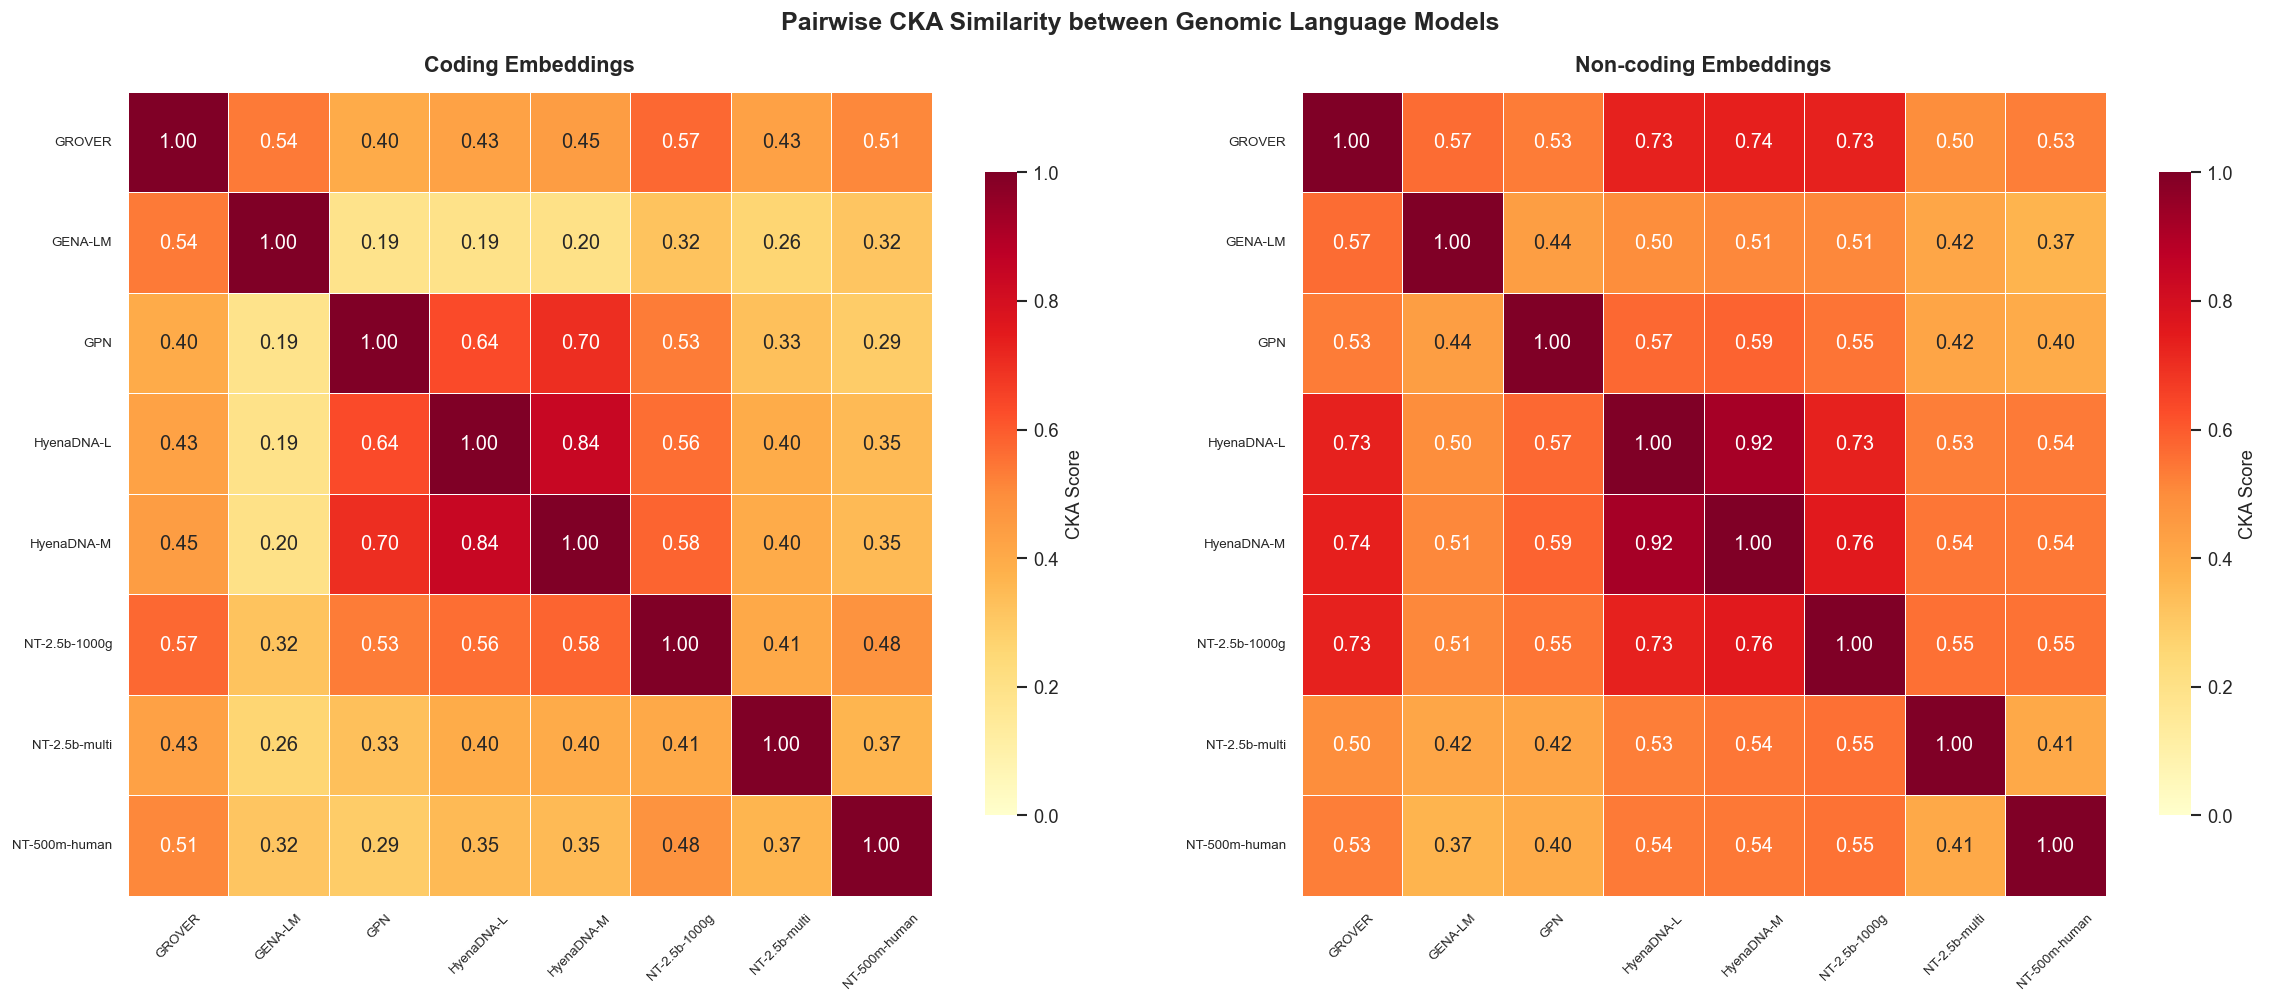

In [9]:
def plot_heatmap(matrix: pd.DataFrame, title: str, ax: plt.Axes) -> None:
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        vmin=0.0,
        vmax=1.0,
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"label": "CKA Score", "shrink": 0.8},
        ax=ax,
    )
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.tick_params(axis="y", labelrotation=0,  labelsize=8)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_heatmap(coding_matrix,    "Coding Embeddings",     axes[0])
plot_heatmap(noncoding_matrix, "Non-coding Embeddings", axes[1])
fig.suptitle("Pairwise CKA Similarity between Genomic Language Models", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig("heatmap_both.png", dpi=150, bbox_inches="tight")
plt.show()

- good agreement btw the hyenaDNA models - but not NT??
- non coding CKA scores seem to be higher for each model on average
- GROVER has good agreement with hyenaDNAs and NT2.5B-1000G
- NT2.5B-1000G has higher CKA scores with other models in both types of sequences than the other NTs - could training data play a role here? why doesn't 500m perform similarly then?

C:\Users\Ruhaib\AppData\Local\Temp\ipykernel_4548\18964736.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


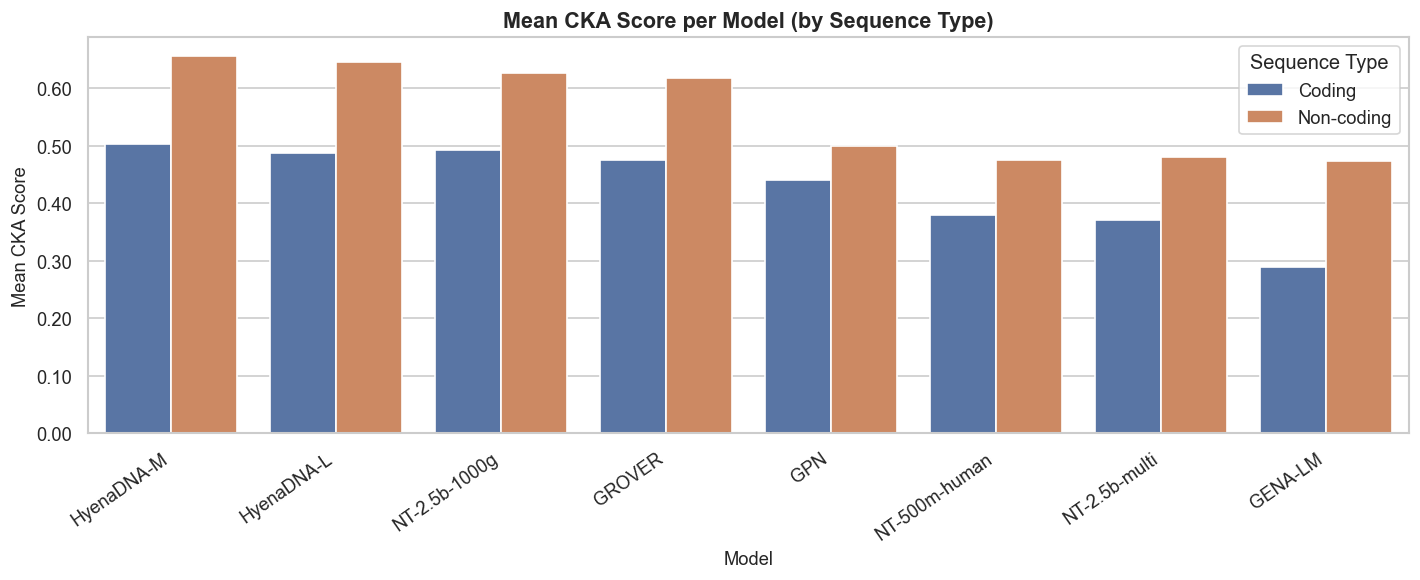

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
model_mean = (
    df_long.groupby(["model", "sequence_type"])["cka_score"]
    .mean()
    .reset_index()
)
order = model_stats.index.tolist()
sns.barplot(
    data=model_mean,
    x="model",
    y="cka_score",
    hue="sequence_type",
    order=order,
    palette={"Coding": "#4C72B0", "Non-coding": "#DD8452"},
    ax=ax,
)
ax.set_title("Mean CKA Score per Model (by Sequence Type)", fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Mean CKA Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.legend(title="Sequence Type")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.show()

C:\Users\Ruhaib\AppData\Local\Temp\ipykernel_4548\808996502.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


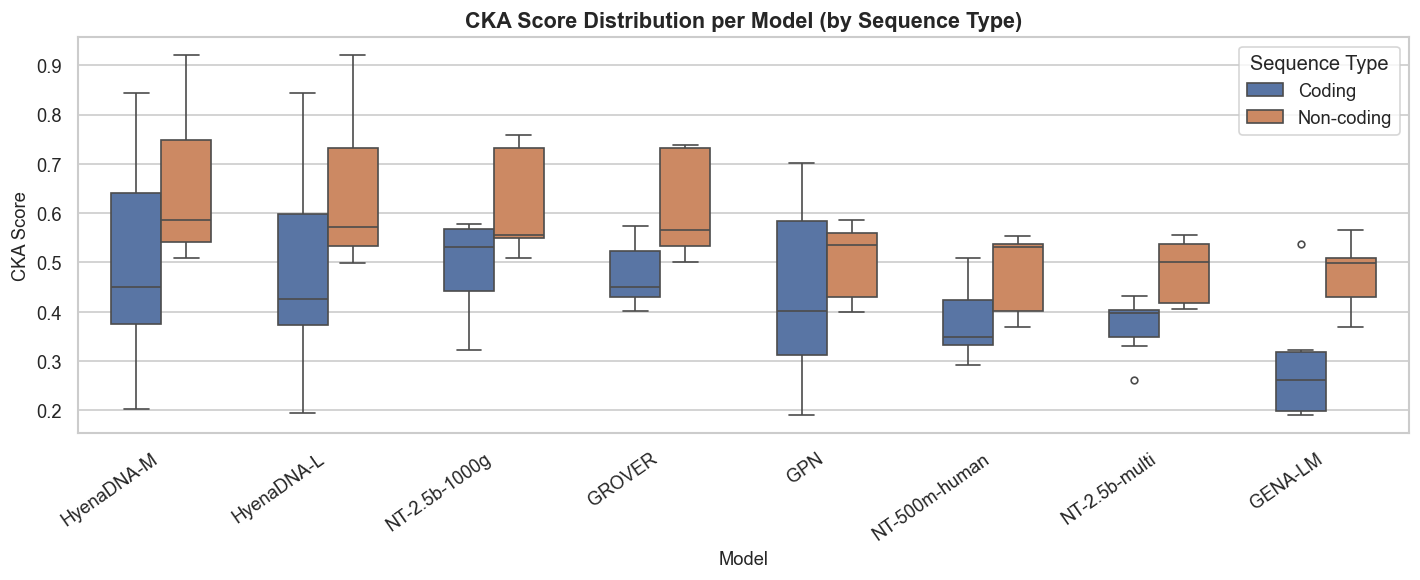

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df_long,
    x="model",
    y="cka_score",
    hue="sequence_type",
    order=order,
    palette={"Coding": "#4C72B0", "Non-coding": "#DD8452"},
    width=0.6,
    flierprops={"marker": "o", "markersize": 4},
    ax=ax,
)
ax.set_title("CKA Score Distribution per Model (by Sequence Type)", fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("CKA Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.legend(title="Sequence Type")
plt.tight_layout()
plt.show()

C:\Users\Ruhaib\AppData\Local\Temp\ipykernel_4548\2449759421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Ruhaib\AppData\Local\Temp\ipykernel_4548\2449759421.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


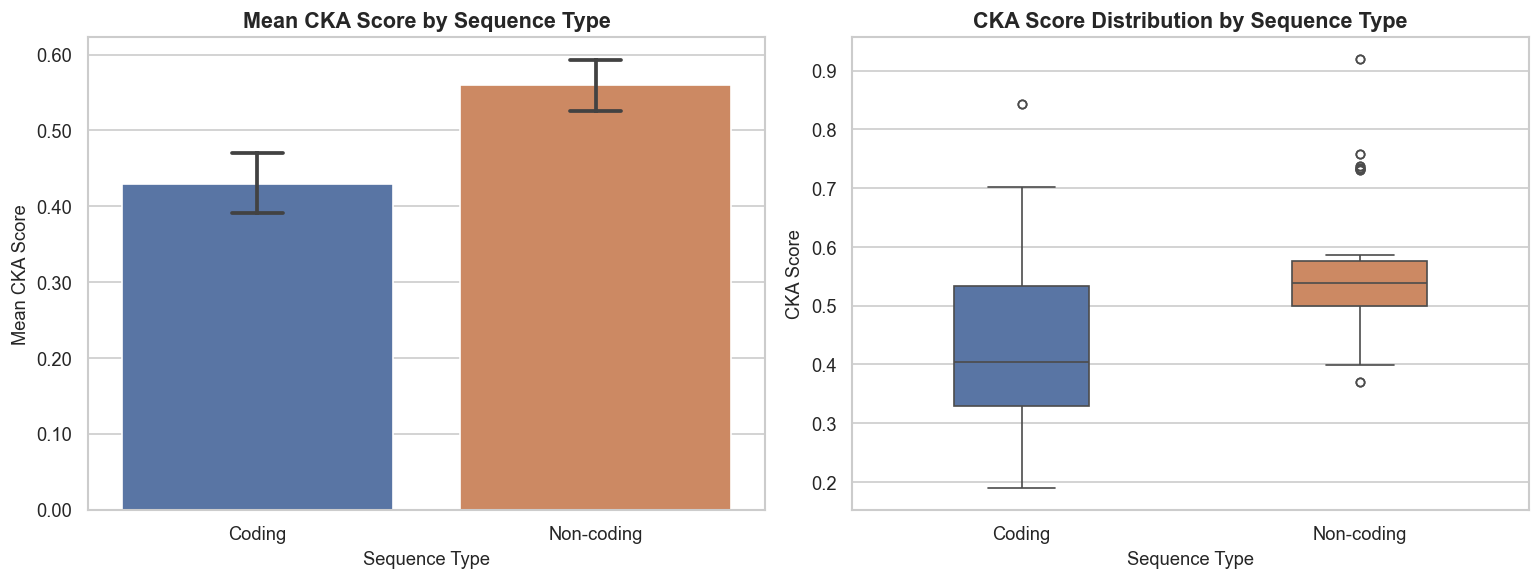

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean per sequence type
sns.barplot(
    data=df_long,
    x="sequence_type",
    y="cka_score",
    palette={"Coding": "#4C72B0", "Non-coding": "#DD8452"},
    capsize=0.15,
    ax=axes[0],
)
axes[0].set_title("Mean CKA Score by Sequence Type", fontweight="bold")
axes[0].set_xlabel("Sequence Type")
axes[0].set_ylabel("Mean CKA Score")
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# Right: box plot
sns.boxplot(
    data=df_long,
    x="sequence_type",
    y="cka_score",
    palette={"Coding": "#4C72B0", "Non-coding": "#DD8452"},
    width=0.4,
    flierprops={"marker": "o", "markersize": 5},
    ax=axes[1],
)
axes[1].set_title("CKA Score Distribution by Sequence Type", fontweight="bold")
axes[1].set_xlabel("Sequence Type")
axes[1].set_ylabel("CKA Score")

plt.tight_layout()
plt.show()

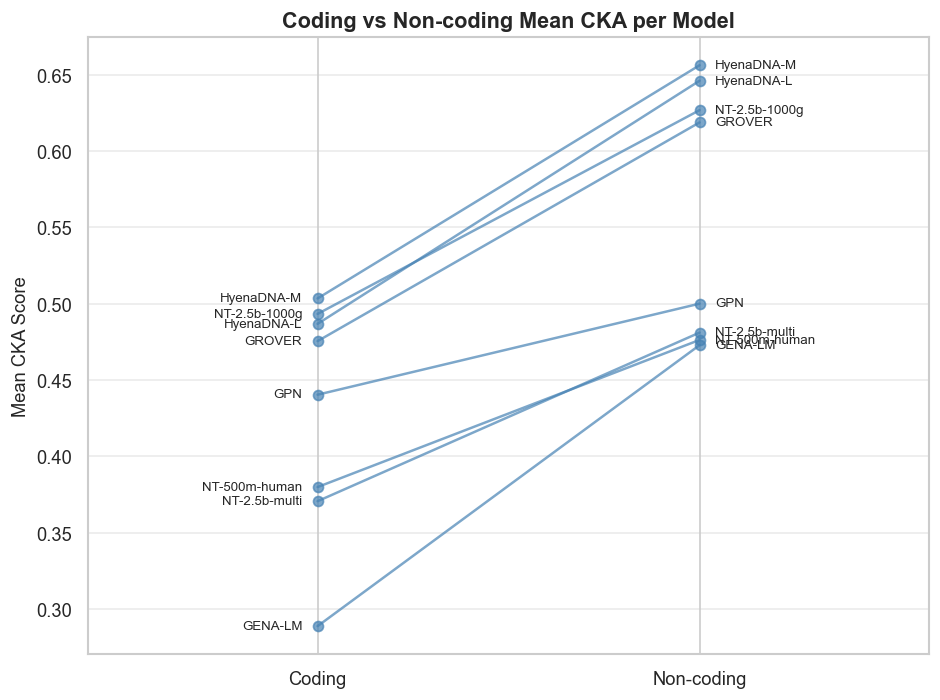

In [ ]:
model_pivot = (
    df_long.groupby(["model", "sequence_type"])["cka_score"]
    .mean()
    .unstack("sequence_type")
    .loc[order]  # preserve sorted order
)

fig, ax = plt.subplots(figsize=(8, 6))
for model, row in model_pivot.iterrows():
    ax.plot([0, 1], [row["Coding"], row["Non-coding"]], "o-", color="steelblue", alpha=0.7, lw=1.5, ms=6)
    ax.text(-0.04, row["Coding"],    model, ha="right", va="center", fontsize=8)
    ax.text( 1.04, row["Non-coding"], model, ha="left",  va="center", fontsize=8)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Coding", "Non-coding"], fontsize=11)
ax.set_xlim(-0.6, 1.6)
ax.set_ylabel("Mean CKA Score")
ax.set_title("Coding vs Non-coding Mean CKA per Model", fontweight="bold")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()